<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

<br>
<h1 style="font-family:verdana; font-size:26px"> <center>Notebook Tugas Besar 2 IF3170 Inteligensi Artifisial 2025/2026</center> </h1>
<br>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# **Group 4 - CriterionIsAllYouNeed**

<p style = "font-size:16px; font-family:verdana"> 13523004 - Razi Rachman Widyadhana<p>

<p style = "font-size:16px; font-family:verdana"> 13523052 - Adhimas Aryo Bimo<p>

<p style = "font-size:16px; font-family:verdana"> 13523105 - Muhammad Fathur Rizky <p>

<p style = "font-size:16px; font-family:verdana"> 13523114- Guntara Hambali <p>

<p style = "font-size:16px; font-family:verdana"> 13523121- Ahmad Wicaksono <p>

<br>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Daftar Isi

1. [**Introduction**](#1)

2. [**Exploratory Data Analysis**](#2)

3. [**Data Preprocessing**](#3)

4. [**Modeling & Validation**](#4)

5. [**Inference**](#6)

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Introduction <a name="1"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## Permasalahan

*Mamalia laut seperti paus, lumba-lumba, dan hiu bergantung pada vokalisasi untuk berkomunikasi, bernavigasi, mencari makan, dan menemukan pasangan. Setiap spesies memiliki pola suara yang unik, sehingga vokalisasi menjadi cara penting untuk mendeteksi keberadaan mereka di lautan.*

*Keragaman pola akustik membuat identifikasi spesies dari audio mentah menjadi sulit tanpa analisis yang tepat. Diperlukan sistem yang mampu mengekstraksi informasi dari rekaman dan mengenali perbedaan vokalisasi antarspesies.*

*Untuk itu, tugas ini bertujuan **membangun model machine learning** yang dapat mengklasifikasikan file audio menjadi spesies mamalia laut yang sesuai dengan menganalisis data audio mentah dan mengenali pola vokalisasi unik setiap spesies.*

---

## Data Gathering

*Data untuk eksperimen ini bersumber dari dataset yang disediakan melalui **Google Drive**, khususnya dari Spesifikasi Tugas Besar 2 AI dengan pranala: https://drive.google.com/drive/folders/1F9bm9juySngtfBT6y2LgigJlBegwCzIA*

*Dataset yang digunakan merupakan gambaran tentang mahasiswa yang terdaftar dalam berbagai program sarjana yang ditawarkan oleh perguruan tinggi.*

*Data ini mencakup data demografis, faktor sosial-ekonomi, dan informasi kinerja akademik yang dapat digunakan untuk menganalisis faktor-faktor yang mungkin memprediksi tingkat kesuksesan akademik mahasiswa.*

---

## Requirements & Config

In [1]:
# %pip install seaborn matplotlib numpy pandas

In [2]:
import numpy as np
import pandas as pd
from scipy.stats import norm

import matplotlib.pyplot as plt
import seaborn as sns

import sys
import os
import io

sys.path.append(os.getcwd())
from allyouneed.base import BaseEstimator, TransformerMixin
from allyouneed.tree import DecisionTreeClassifier
from allyouneed.svm import MulticlassSVC
from allyouneed.model_selection import StratifiedKFold
from allyouneed.metrics import Accuracy, F1Score
from allyouneed.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler, MinMaxScaler
from allyouneed.feature_selection import ForwardFeatureSelection, BackwardFeatureElimination
from allyouneed.decomposition import PCA

# Benchmark models from sklearn
from sklearn.tree import DecisionTreeClassifier as SklearnDecisionTreeClassifier
from sklearn.svm import SVC as SklearnSVC
from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression
from sklearn.decomposition import PCA as SklearnPCA

import warnings
warnings.filterwarnings("ignore")

In [3]:
class settings:
    DATA_DIR = "../dataset/"
    TRAIN_FILE = "train.csv"
    TEST_FILE = "test.csv"
    SUBMISSION_FILE = "sample_submission.csv"
    INDEX_COL = "Student_ID"
    SEED = 42
    TARGET = "Target"
    TRAIN_PATH = DATA_DIR + TRAIN_FILE
    TEST_PATH = DATA_DIR + TEST_FILE
    SUBMISSION_PATH = DATA_DIR + SUBMISSION_FILE

In [4]:
np.random.seed(settings.SEED)
pd.set_option('display.max_columns', None)

rc_params = {
    "grid.color": "#EBEBE7",
    "font.family": "serif",
}

plt.rcParams.update(rc_params)

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Exploratory Data Analysis <a name="2"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## Muat Dataset

In [5]:
train = pd.read_csv(settings.TRAIN_PATH, index_col=settings.INDEX_COL)
test = pd.read_csv(settings.TEST_PATH, index_col=settings.INDEX_COL)
submission = pd.read_csv(settings.SUBMISSION_PATH, index_col=settings.INDEX_COL)

In [6]:
train

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
Student_ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
3743,1,17,1,9670,1,1,118.0,1,19,38,7,9,113.5,1,0,0,1,0,1,19,0,0,6,9,5,13.500000,0,0,6,6,6,14.000000,0,12.4,0.5,1.79,Graduate
3540,1,1,1,9070,1,1,139.0,1,1,19,3,9,134.9,1,0,0,1,1,0,20,0,0,6,7,6,13.666667,0,0,6,7,6,12.166667,1,16.2,0.3,-0.92,Graduate
1118,1,1,1,9500,1,1,138.0,1,38,19,9,5,144.3,0,0,0,1,0,0,20,0,0,7,9,6,12.700000,0,0,8,8,7,13.571429,0,13.9,-0.3,0.79,Graduate
791,1,17,1,9773,1,1,138.0,1,1,19,9,9,124.0,0,0,0,1,0,1,19,0,0,6,6,6,13.166667,0,0,6,6,6,13.833333,0,11.1,0.6,2.02,Graduate
4381,1,7,1,9500,1,2,140.0,1,38,37,7,8,140.0,0,0,0,1,0,0,29,0,0,8,14,4,11.325000,1,0,8,14,4,11.325000,1,12.7,3.7,-1.70,Dropout
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
898,1,43,1,9070,1,39,130.0,1,19,37,5,9,124.0,1,0,0,1,0,1,21,0,4,12,12,12,13.333333,0,5,12,12,11,12.545455,0,15.5,2.8,-4.06,Graduate
1998,1,17,1,9773,1,1,121.0,1,37,37,9,9,122.4,0,0,0,1,0,0,18,0,0,6,7,6,12.857143,0,0,6,6,6,13.333333,0,13.9,-0.3,0.79,Graduate
72,1,17,1,9500,1,1,150.0,1,37,19,8,4,130.8,0,0,0,1,1,0,24,0,0,7,8,7,11.975000,0,0,8,8,8,13.750000,0,13.9,-0.3,0.79,Graduate


---

## Normalisasi Nama Kolom

In [7]:
train.columns = train.columns.str.replace(r'\s+', '_', regex=True).str.replace('/', '_').str.replace("'", '').str.strip('_')
test.columns = test.columns.str.replace(r'\s+', '_', regex=True).str.replace('/', '_').str.replace("'", '').str.strip('_')

---

## Tipe Data tiap Fitur

In [8]:
buffer = io.StringIO()
train.info(buf=buffer)

lines = buffer.getvalue().splitlines()
types_info = (pd.DataFrame([x.split() for x in lines[5:-2]], columns=lines[3].split())).drop(['Count', 'Non-Null', '#'], axis=1)
types_info.set_index('Column')

,Dtype
Column,
Marital_status,int64
Application_mode,int64
Application_order,int64
Course,int64
Daytime_evening_attendance,int64
Previous_qualification,int64
Previous_qualification_(grade),float64
Nacionality,int64
Mothers_qualification,int64


---

## Unique Values

In [9]:
train.nunique().to_frame(name='nunique')

,nunique
Marital_status,6
Application_mode,18
Application_order,8
Course,17
Daytime_evening_attendance,2
Previous_qualification,17
Previous_qualification_(grade),96
Nacionality,17
Mothers_qualification,28
Fathers_qualification,32


---

## Data Duplikat

In [10]:
train[train.duplicated(keep=False)]

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_(grade),Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_(credited),Curricular_units_1st_sem_(enrolled),Curricular_units_1st_sem_(evaluations),Curricular_units_1st_sem_(approved),Curricular_units_1st_sem_(grade),Curricular_units_1st_sem_(without_evaluations),Curricular_units_2nd_sem_(credited),Curricular_units_2nd_sem_(enrolled),Curricular_units_2nd_sem_(evaluations),Curricular_units_2nd_sem_(approved),Curricular_units_2nd_sem_(grade),Curricular_units_2nd_sem_(without_evaluations),Unemployment_rate,Inflation_rate,GDP,Target
Student_ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,


---

# Missing Values

In [11]:
missing_count = train.isnull().sum().rename('Missing Count')
missing_ratio = (train.isnull().mean()*100).rename('Missing Percentage (%)')
summary = missing_count.to_frame().join(missing_ratio.to_frame())
summary.sort_values(["Missing Percentage (%)"], ascending = [0])

,Missing Count,Missing Percentage (%)
Marital_status,0,0.0
Age_at_enrollment,0,0.0
Curricular_units_1st_sem_(credited),0,0.0
Curricular_units_1st_sem_(enrolled),0,0.0
Curricular_units_1st_sem_(evaluations),0,0.0
Curricular_units_1st_sem_(approved),0,0.0
Curricular_units_1st_sem_(grade),0,0.0
Curricular_units_1st_sem_(without_evaluations),0,0.0
Curricular_units_2nd_sem_(credited),0,0.0
Curricular_units_2nd_sem_(enrolled),0,0.0


In [12]:
# # 1. Pilih kolom int64
# int_cols = train.select_dtypes(include="int64").columns

# # 2. Salinan agar tidak mengubah train asli
# df_cat = train[int_cols].copy()

# # 3. Convert semua kolom int ke categorical (object)
# df_cat = df_cat.astype("object")

# # 4. Hitung nunique dan mode
# summary = []

# for col in df_cat.columns:
#     nunique = df_cat[col].nunique()
#     mode = df_cat[col].mode().iloc[0] if nunique > 0 else None
#     summary.append({
#         "column": col,
#         "nunique": nunique,
#         "mode": mode
#     })

# summary_df = pd.DataFrame(summary)

# summary_df.loc[summary_df['nunique'] > 2].column.values

---

## Statistika Deskriptif

Dari insight sebelumnya, yaudah pisah jadi fitur numerical dan fitur categorical.

Biar enak preprocessing sama EDA yang sesuai untuk setiap jenis fitur sehingga model dapat mempelajari data dengan lebih efektif dan menghasilkan prediksi yang lebih akurat.

In [13]:
col = list(train.columns)
col.remove("Target")

num_features = ["Previous_qualification_(grade)",
                "Admission_grade",
                "Age_at_enrollment",
                "Curricular_units_1st_sem_(credited)",
                "Curricular_units_1st_sem_(enrolled)",
                "Curricular_units_1st_sem_(evaluations)",
                "Curricular_units_1st_sem_(approved)",
                "Curricular_units_1st_sem_(grade)",
                "Curricular_units_1st_sem_(without_evaluations)",
                "Curricular_units_2nd_sem_(credited)",
                "Curricular_units_2nd_sem_(enrolled)",
                "Curricular_units_2nd_sem_(evaluations)",
                "Curricular_units_2nd_sem_(approved)",
                "Curricular_units_2nd_sem_(grade)",
                "Curricular_units_2nd_sem_(without_evaluations)",
                "Unemployment_rate",
                "Inflation_rate",
                "GDP"]

ord_features = ["Application_order", 
                "Previous_qualification"]

bin_features = [feat for feat in col if train[feat].nunique() == 2 and feat not in ord_features]

cat_features = ["Marital_status",
                "Application_mode",
                "Course",
                "Nacionality",
                "Mothers_qualification",
                "Fathers_qualification",
                "Mothers_occupation",
                "Fathers_occupation"]

print("Numerical Features:", len(num_features)
      , "\nOrdinal Features:", len(ord_features)
      , "\nBinary Features:", len(bin_features)
      , "\nCategorical Features:", len(cat_features)
      , "\nTotal Features (without id and target):", len(num_features) + len(ord_features) + len(bin_features) + len(cat_features))

Numerical Features: 18 
Ordinal Features: 2 
Binary Features: 8 
Categorical Features: 8 
Total Features (without id and target): 36


### Distribusi `Target`

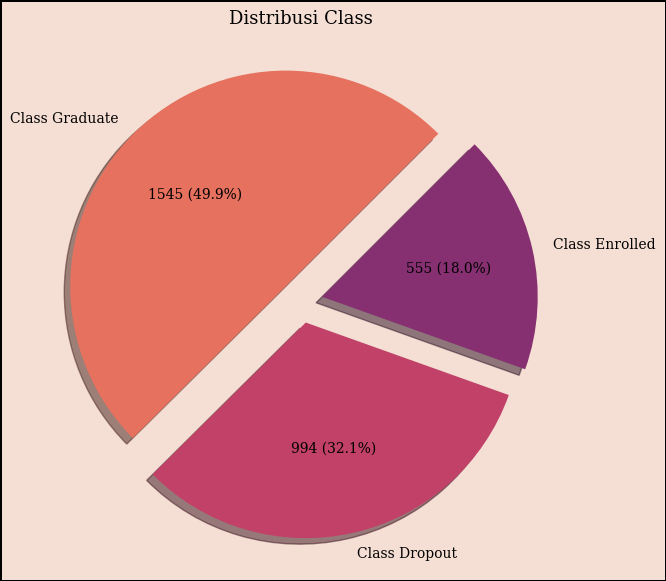

In [14]:
fig, ax = plt.subplots(figsize=(7, 7), facecolor='#f5ded3')
fig.patch.set_linewidth(2)  
fig.patch.set_edgecolor('black')

value_counts = train['Target'].value_counts()
counts = value_counts.values
labels = value_counts.index

colors = sns.color_palette('flare', n_colors=len(labels))

def autopct_format(pct):
    absolute = int(pct/100.*counts.sum())
    return f'{absolute} ({pct:.1f}%)'

ax = plt.pie(counts,
             labels=[f'Class {label}' for label in labels],
             autopct=autopct_format,
             explode=[0.1] * len(labels),
             colors=colors,
             shadow=True,
             startangle=45
)

plt.title('Distribusi Class', fontsize=13)
plt.show()

### `num_features`

In [15]:
train[num_features + ord_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Previous_qualification_(grade),3096.0,132.762435,13.137942,95.00,125.00,133.100000,140.000000,190.000000
Admission_grade,3096.0,126.915698,14.459928,95.00,117.80,126.000000,135.000000,190.000000
Age_at_enrollment,3096.0,23.216408,7.614394,17.00,19.00,20.000000,25.000000,70.000000
Curricular_units_1st_sem_(credited),3096.0,0.713501,2.365945,0.00,0.00,0.000000,0.000000,20.000000
Curricular_units_1st_sem_(enrolled),3096.0,6.245801,2.501305,0.00,5.00,6.000000,7.000000,26.000000
Curricular_units_1st_sem_(evaluations),3096.0,8.242571,4.186787,0.00,6.00,8.000000,10.000000,45.000000
Curricular_units_1st_sem_(approved),3096.0,4.697674,3.087995,0.00,3.00,5.000000,6.000000,26.000000
Curricular_units_1st_sem_(grade),3096.0,10.621631,4.880632,0.00,11.00,12.333333,13.400000,18.875000
Curricular_units_1st_sem_(without_evaluations),3096.0,0.140181,0.672843,0.00,0.00,0.000000,0.000000,12.000000
Curricular_units_2nd_sem_(credited),3096.0,0.539729,1.906634,0.00,0.00,0.000000,0.000000,19.000000


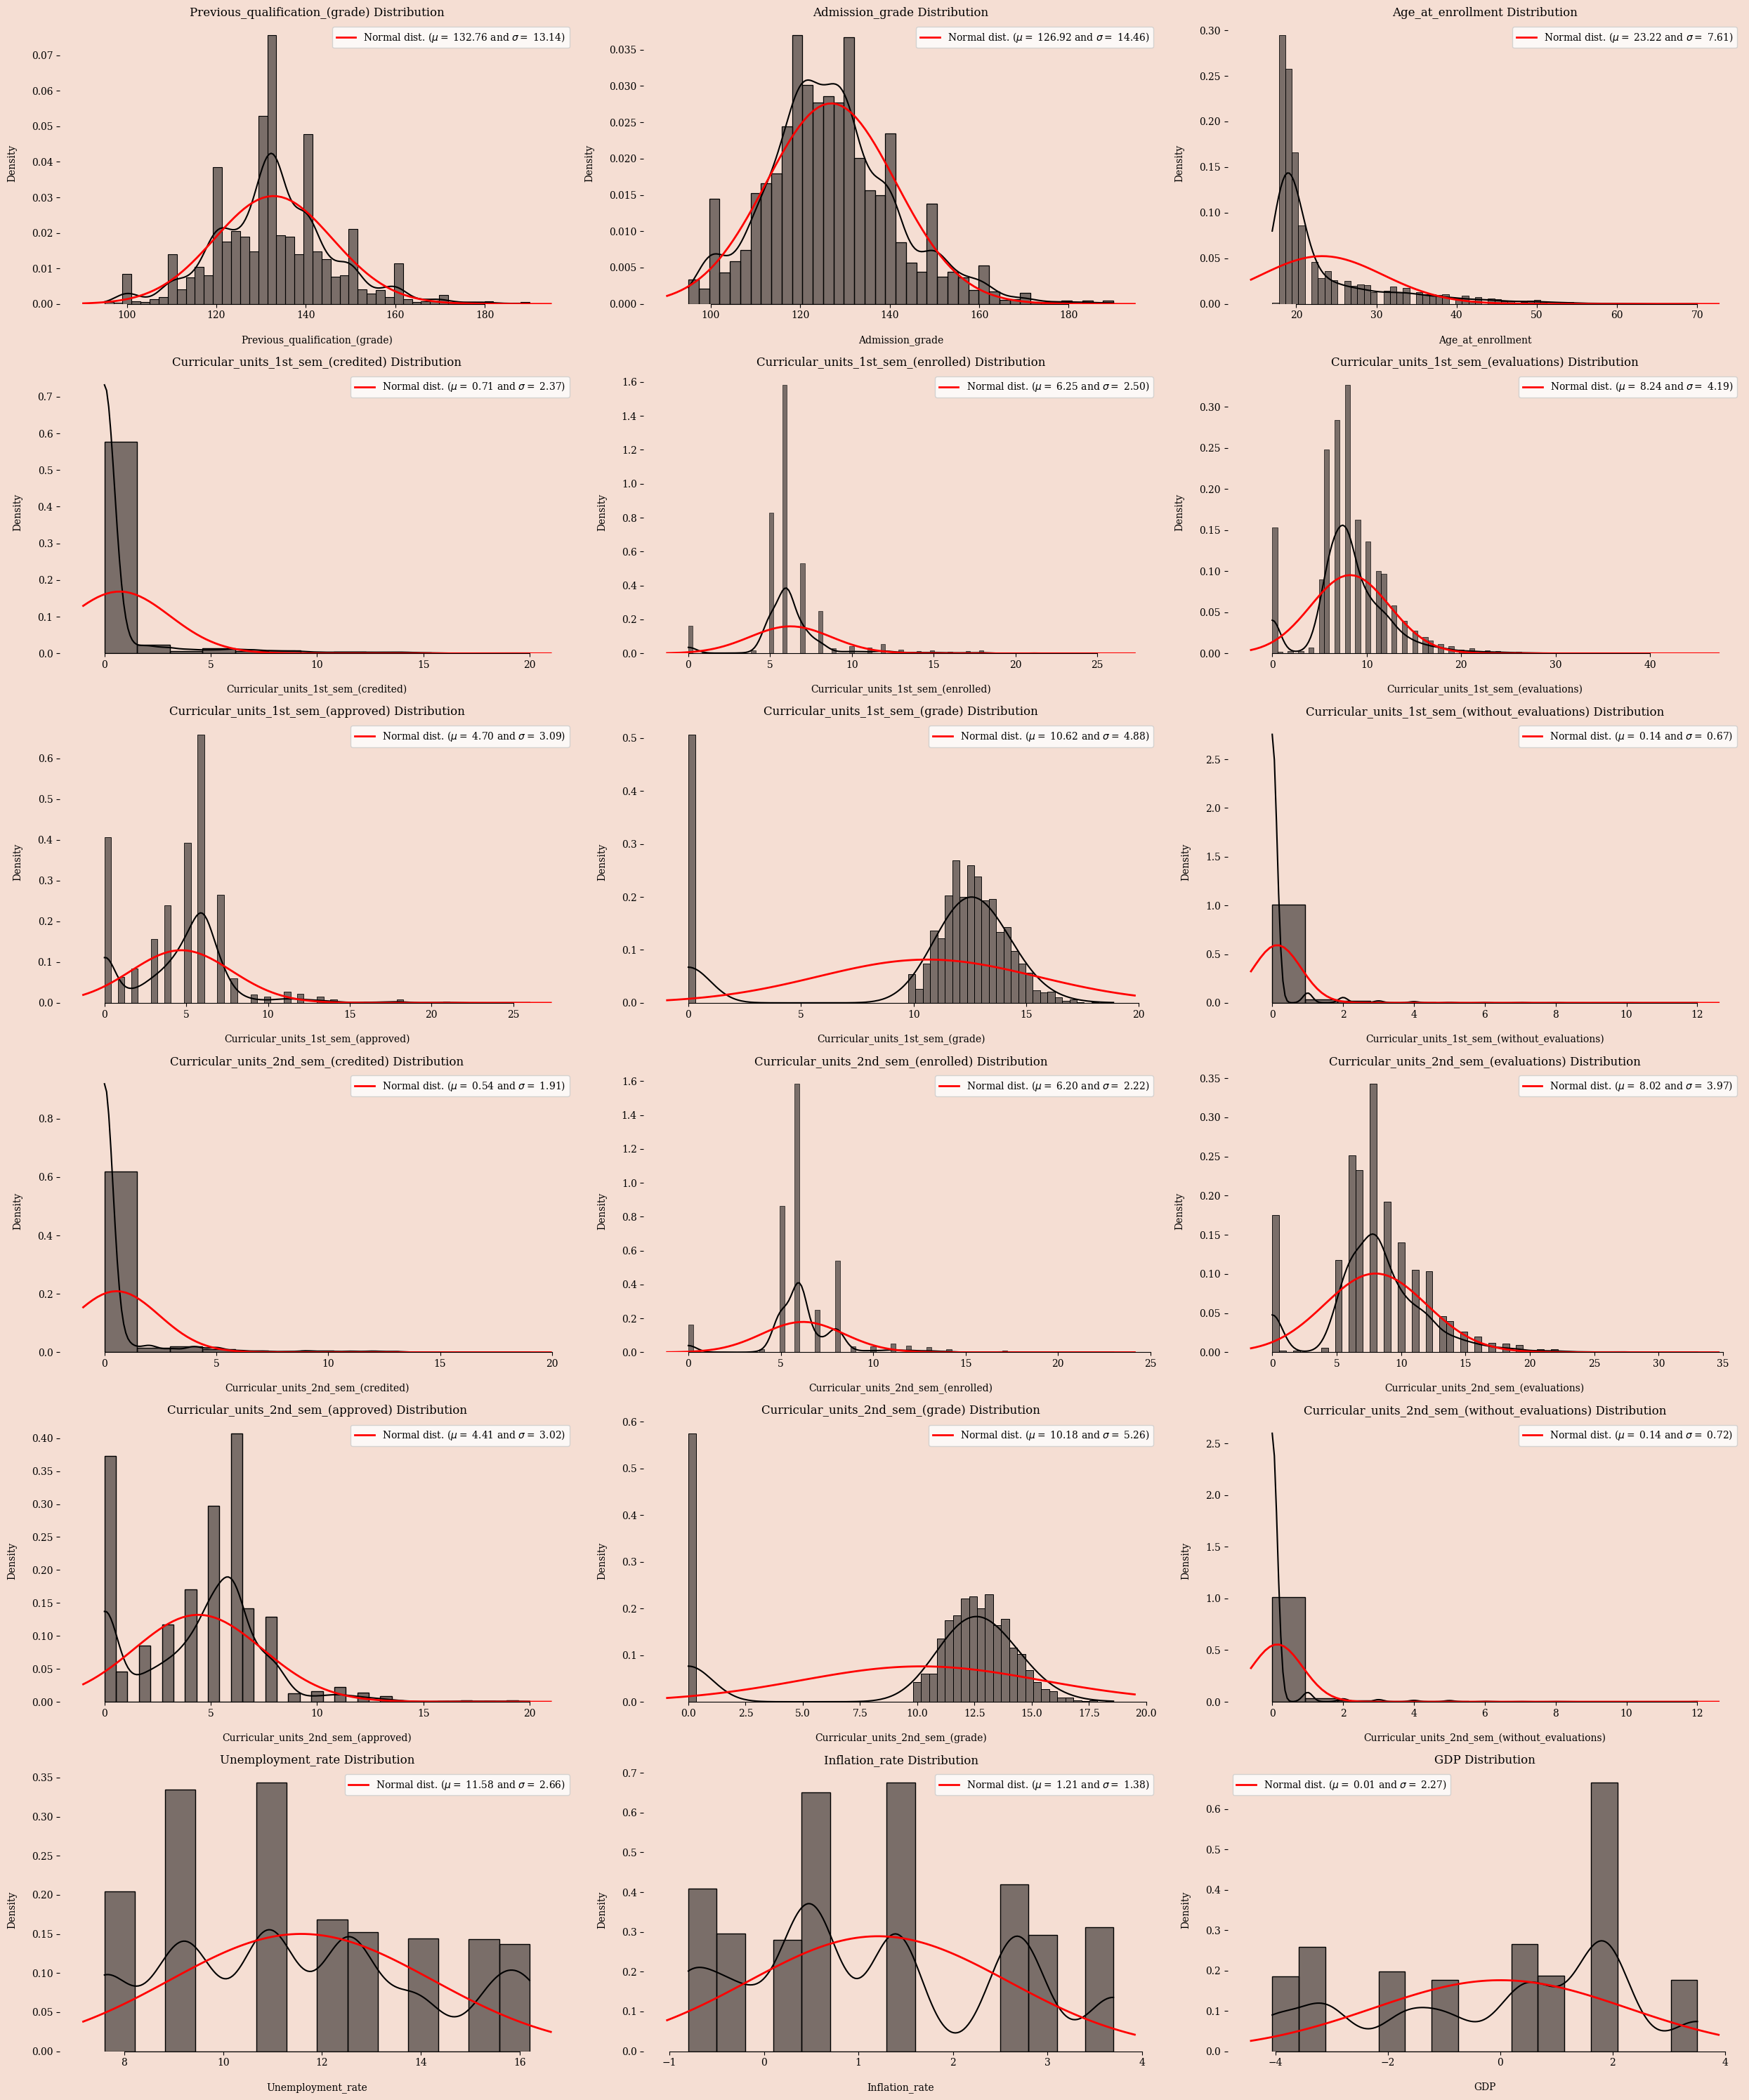

In [16]:
n_features = len(num_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

plt.figure(figsize=(25, 5 * n_rows), facecolor='#f5ded3')

for index, feature in enumerate(num_features):
    
    ax = plt.subplot(n_rows, n_cols, index + 1)
    sns.histplot(data=train, x=feature, kde=True, stat='density', color='#000000', ax=ax)
    
    feature_data = train[feature].dropna()
    (mu, sigma) = norm.fit(feature_data)
    
    xmin, xmax = ax.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, sigma)
    
    ax.plot(x, p, 'r-', linewidth=2, label=f'Normal dist. ($\\mu=$ {mu:.2f} and $\\sigma=$ {sigma:.2f})')
    
    ax.legend(loc='best')
    ax.xaxis.grid(False)
    ax.set_facecolor('#f5ded3')
    ax.set_ylabel("Density", labelpad=15)
    ax.set_xlabel(feature, labelpad=15)  
    ax.set_title(f"{feature} Distribution")
    sns.despine(trim=True, left=True)

plt.tight_layout()
plt.show()

---

## Outliers?

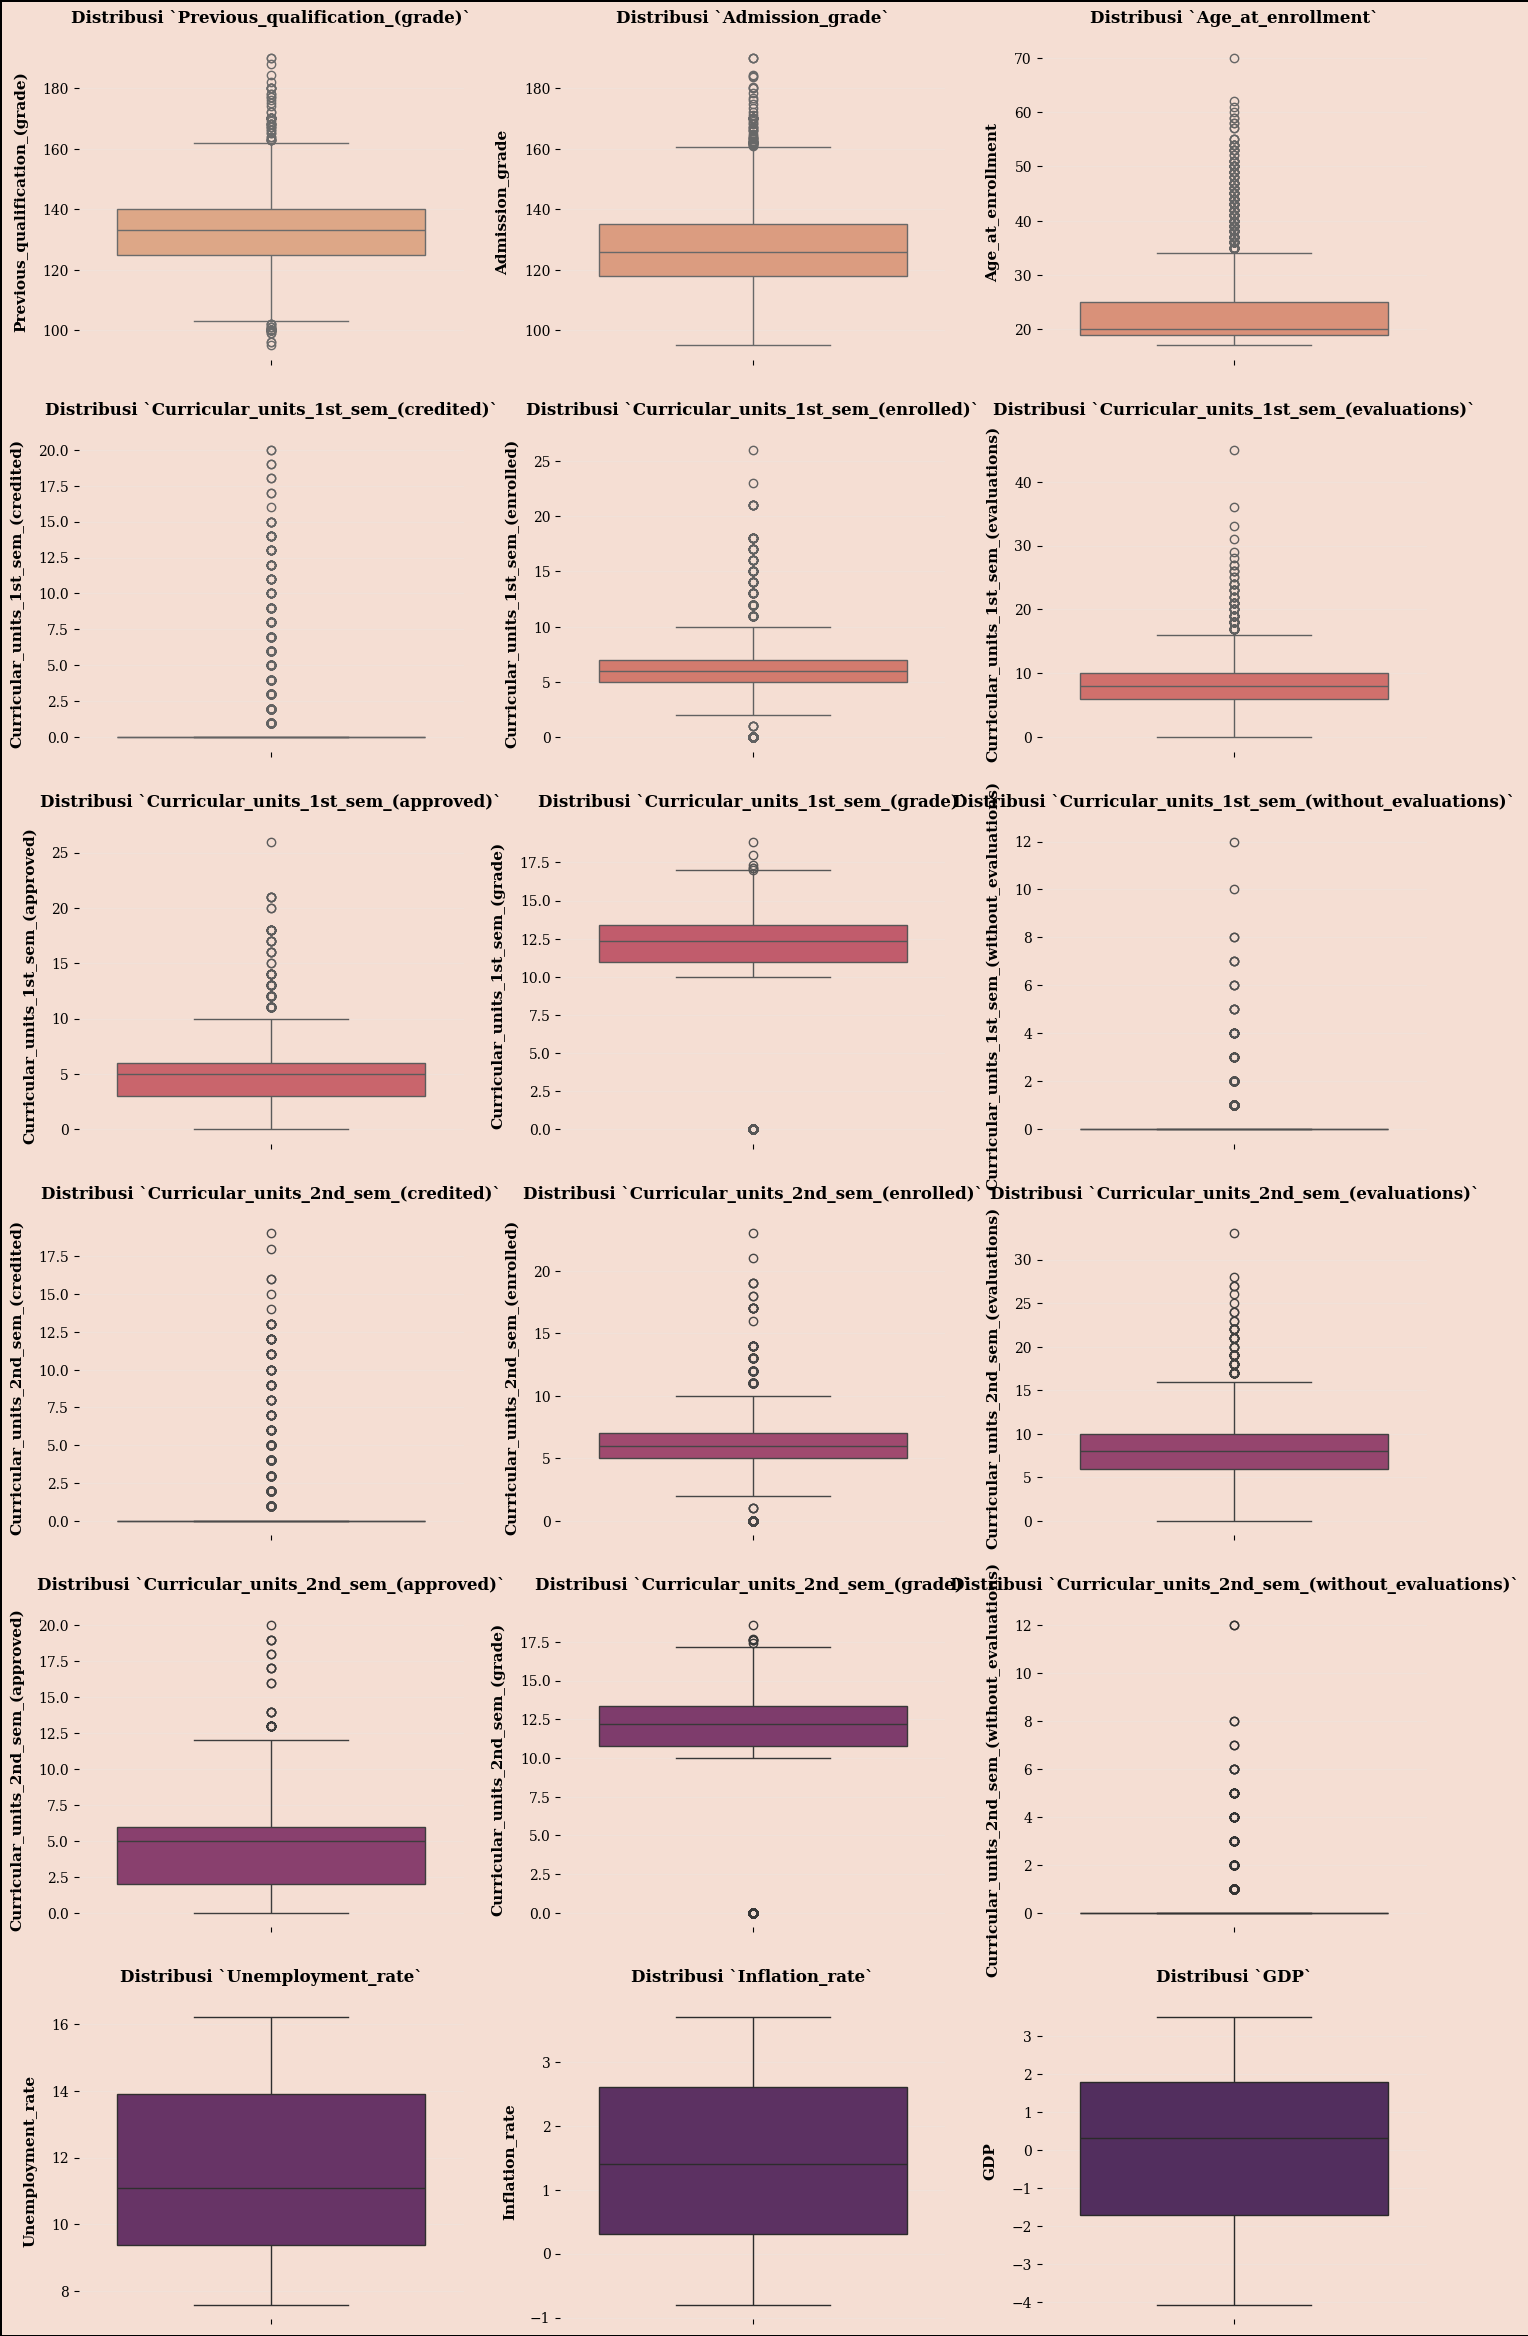

In [17]:
n_features = len(num_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4), facecolor='#f5ded3')
fig.patch.set_linewidth(2)
fig.patch.set_edgecolor('black')

if n_rows == 1:
    axes = axes if n_features > 1 else [axes]
else:
    axes = axes.flatten()

colors = sns.color_palette('flare', n_features)

for i, feature in enumerate(num_features):
    ax = axes[i]
    
    sns.boxplot(data=train, y=feature, palette=[colors[i]], ax=ax)
    
    ax.set_facecolor('#f5ded3')
    ax.set_title(f'Distribusi `{feature}`', fontsize=12, fontweight='bold', pad=15)
    ax.set_ylabel(feature, fontsize=11, fontweight='bold', labelpad=10)
    ax.tick_params(axis='y', labelsize=10)
    ax.tick_params(axis='x', labelsize=10)
    
    ax.set_xlabel('')
    
    ax.grid(True, alpha=0.3, axis='y')
    
    sns.despine(ax=ax, trim=True, left=True)

for i in range(n_features, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout(pad=3.0, h_pad=3.0, w_pad=2.0)
plt.show()

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Preprocessing <a name="3"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## Data Transformation & Dimensionality Reduction

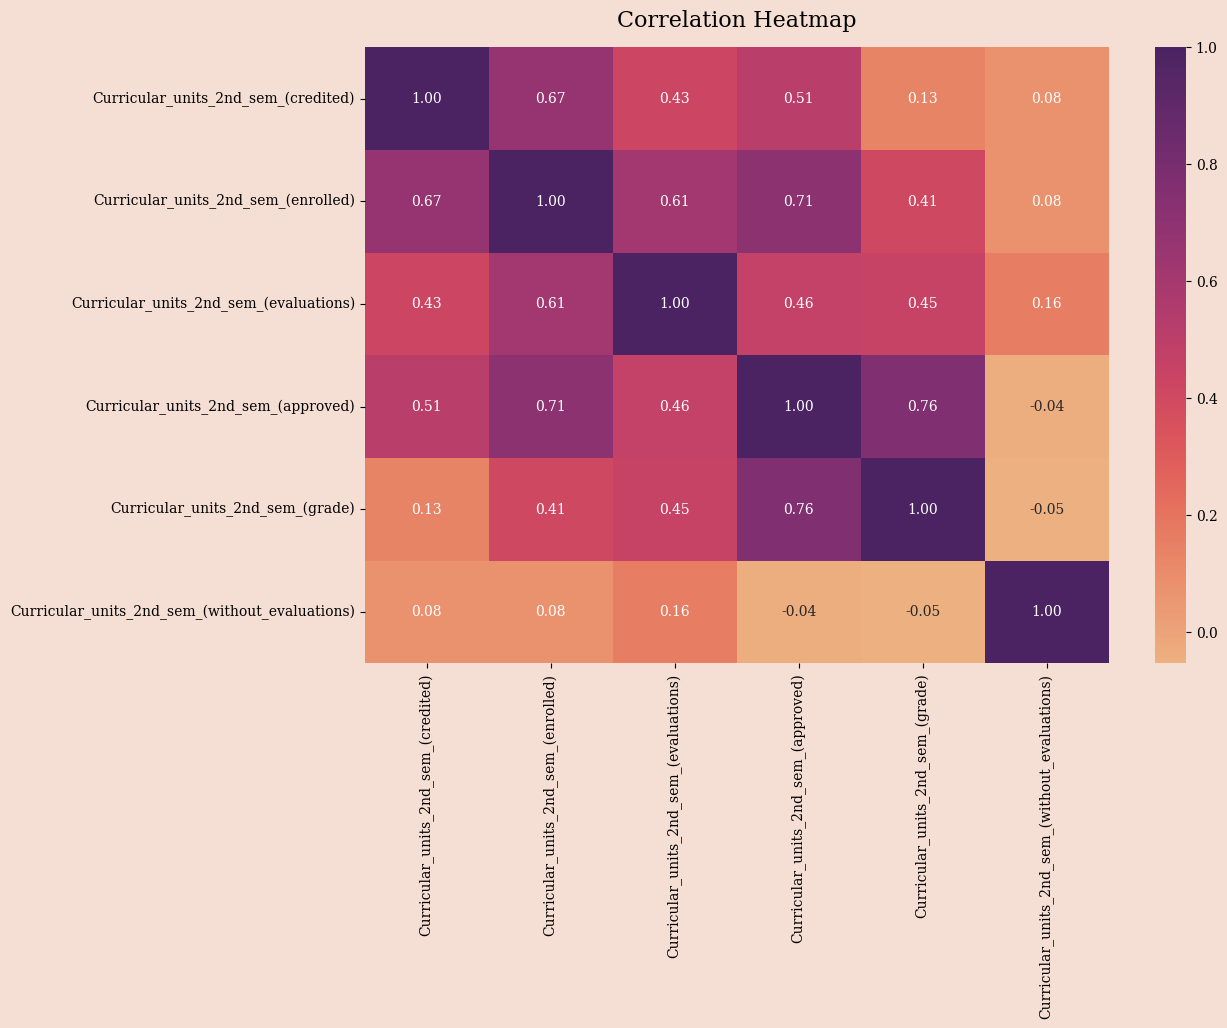

In [18]:
plt.figure(figsize=(12, 8), facecolor='#f5ded3')

sns.heatmap(train[['Curricular_units_2nd_sem_(credited)',
                'Curricular_units_2nd_sem_(enrolled)',
                'Curricular_units_2nd_sem_(evaluations)',
                'Curricular_units_2nd_sem_(approved)',
                'Curricular_units_2nd_sem_(grade)',
                'Curricular_units_2nd_sem_(without_evaluations)',]].select_dtypes(include=[np.number]).corr(), annot=True, fmt=".2f", cmap='flare')

plt.title('Correlation Heatmap', fontsize=16, pad=15)
plt.show()

In [19]:
label_encoder = LabelEncoder()
label_encoder.fit(train[settings.TARGET])

class Preprocessing(BaseEstimator, TransformerMixin):
    def __init__(self, categorical_cols=None, dropped_cols=None, z_threshold=3.0, pca_n_components=None):
        self.categorical_cols = categorical_cols or []
        self.dropped_cols = dropped_cols or []
        self.ohe = OneHotEncoder(columns=self.categorical_cols, dtype=float)
        self.scaler = StandardScaler()
        self.numeric_cols = []
        self.fitted = False
        
        self.z_threshold = z_threshold
        self.zscore_params = {}
        
        self.pca_n_components = pca_n_components
        self.pca = None
        self.cumsum_ = None
        self.n_components_for_variance_ = None
        if self.pca_n_components is not None:
            self.pca = PCA(n_components=pca_n_components)

    def fit(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            raise ValueError("X must be a pandas DataFrame")

        if self.dropped_cols:
            X = X.drop(columns=self.dropped_cols)

        self.numeric_cols = (
            X.select_dtypes(include=[np.number])
             .columns
             .difference(self.categorical_cols)
             .tolist()
        )

        self.zscore_params = {}
        for col in self.numeric_cols:
            mean = X[col].mean()
            std = X[col].std()
            self.zscore_params[col] = (mean, std)

        self.ohe.fit(X)
        self.scaler.fit(X[self.numeric_cols])
        
        if self.pca is not None:
            X_temp = self._preprocess_without_pca(X)
            self.pca.fit(X_temp)
            self.cumsum_ = np.cumsum(self.pca.explained_variance_ratio_)
            self.n_components_for_variance_ = {}
            for threshold in [0.90, 0.95, 0.99]:
                n_comps = np.argmax(self.cumsum_ >= threshold) + 1
                self.n_components_for_variance_[threshold] = n_comps

        self.fitted = True
        return self

    def _preprocess_without_pca(self, X):
        if self.dropped_cols:
            X = X.drop(columns=self.dropped_cols)

        X_num = X[self.numeric_cols].astype(float)

        for col in self.numeric_cols:
            mean, std = self.zscore_params[col]
            z = (X_num[col] - mean) / std
            z = z.clip(-self.z_threshold, self.z_threshold)
            X_num[col] = z * std + mean

        X_cat_array = self.ohe.transform(X)
        X_cat = pd.DataFrame(
            X_cat_array,
            columns=self.ohe.feature_names_,
            index=X.index
        )

        X_num_scaled = self.scaler.transform(X_num)
        X_num = pd.DataFrame(X_num_scaled, columns=self.numeric_cols, index=X.index)

        return pd.concat([X_num, X_cat], axis=1)

    def transform(self, X):
        if not self.fitted:
            raise ValueError("Preprocessing must be fitted before transform()")

        X_preprocessed = self._preprocess_without_pca(X)
        
        if self.pca is not None:
            return self.pca.transform(X_preprocessed)
        
        return X_preprocessed

DROPPED_COLS = []
cat_features = [col for col in cat_features if col not in DROPPED_COLS]

# Without PCA
# preprocessor = Preprocessing(
#   categorical_cols=cat_features, 
#   dropped_cols=DROPPED_COLS
# )

# With PCA
preprocessor = Preprocessing(
    categorical_cols=cat_features, 
    dropped_cols=DROPPED_COLS,
    pca_n_components=0.95
)

X_train = preprocessor.fit_transform(train.drop(columns=[settings.TARGET]))
y_train = label_encoder.transform(train[settings.TARGET])

if preprocessor.pca is not None:
    print(f"Components for 95% variance: {preprocessor.n_components_for_variance_[0.95]}")

Components for 95% variance: 48


In [22]:
X_train = pd.DataFrame(X_train, columns=[f'PC{i+1}' for i in range(X_train.shape[1])])

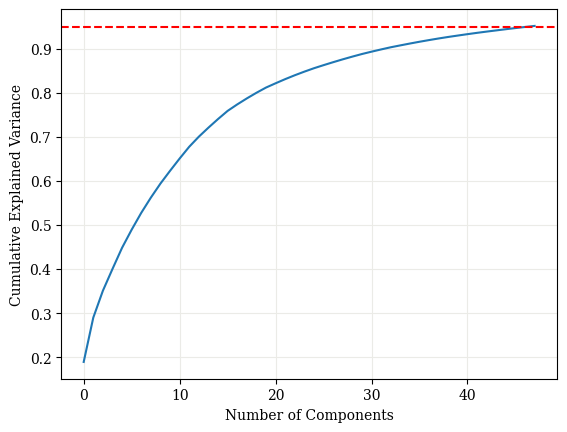

In [20]:
import matplotlib.pyplot as plt
plt.plot(preprocessor.cumsum_)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.95, color='r', linestyle='--')
plt.grid()
plt.show()

---

## Feature Selection

In [ ]:
fs = ForwardFeatureSelection(
    estimator=SklearnSVC(kernel='rbf', C=1.0, class_weight='balanced'),
    n_features_to_select=15,
    scoring=F1Score(average='macro'),
    verbose=True,
    feature_names=X_train.columns.tolist(),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=settings.SEED),
)

# fs = BackwardFeatureElimination(
#     estimator=SklearnDecisionTreeClassifier(criterion='entropy', class_weight='balanced'),
#     n_features_to_select=15,
#     scoring=F1Score(average='macro'),
#     verbose=True,
#     feature_names=X_train.columns.tolist(),
#     cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=settings.SEED),
# )

In [ ]:
fs.fit(X_train, y_train)
# # fs.selected_features_

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Modeling & Validation <a name="4"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## Metrics

In [ ]:
class ConfusionMatrix:
    def __call__(self, y_true, y_pred):
        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)

        labels = np.unique(np.concatenate([y_true, y_pred]))
        label_to_idx = {label: idx for idx, label in enumerate(labels)}
        
        cm = np.zeros((len(labels), len(labels)), dtype=int)

        for t, p in zip(y_true, y_pred):
            cm[label_to_idx[t], label_to_idx[p]] += 1
        
        return cm, labels

class MetricCollection:
    def __init__(self, metrics: dict):
        """
        metrics: dict[name -> Metric instance]
        """
        self.metrics = metrics

    def __call__(self, y_true, y_pred):
        return {name: metric(y_true, y_pred) for name, metric in self.metrics.items()}

---

## Training

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=settings.SEED)

models = {
    'DT': DecisionTreeClassifier(random_state=settings.SEED),
    'SVC': MulticlassSVC(kernel='rbf', C=1.0, random_state=settings.SEED),
}

metrics = MetricCollection({
    'accuracy': Accuracy(),
    'f1_macro': F1Score(average='macro'),
    'f1_micro': F1Score(average='micro'),
    'f1_weighted': F1Score(average='weighted')  
})

all_results = {} 

In [ ]:
for name, model in models.items():
    print(f"Training model: {name}")
    fold_results = []  # store metric dict for each fold

    for fold, (train_idx, val_idx) in enumerate(skf.split(train, train[settings.TARGET])):
    
        X_train = train.drop(columns=[settings.TARGET]).iloc[train_idx]
        y_train_raw = train[settings.TARGET].iloc[train_idx].values
        y_train = label_encoder.transform(y_train_raw)

        X_val = train.drop(columns=[settings.TARGET]).iloc[val_idx]
        y_val_raw = train[settings.TARGET].iloc[val_idx].values
        y_val = label_encoder.transform(y_val_raw)

        train_data = preprocessor.fit_transform(X_train)
        val_data = preprocessor.transform(X_val)

        model.fit(train_data, y_train)
        val_preds = model.predict(val_data)

        results = metrics(y_val, val_preds)
        fold_results.append(results)

        print(f"Fold {fold + 1} results: {results}")

    df_results = pd.DataFrame(fold_results)
    model_mean = df_results.mean().to_dict()

    all_results[name] = {
        "per_fold": fold_results,
        "mean": model_mean
    }

    print(f"\nAggregated results for model {name}:")
    print(df_results)
    print("Mean metrics:", model_mean)
    print("=" * 60)

Training model: DT
Fold 1 results: {'accuracy': 0.6183574879227053, 'f1_macro': 0.5645541977237634, 'f1_micro': 0.6183574879227053, 'f1_weighted': 0.6237346022404094}
Fold 2 results: {'accuracy': 0.6235864297253635, 'f1_macro': 0.5620166998606786, 'f1_micro': 0.6235864297253635, 'f1_weighted': 0.6270939723695367}
Fold 3 results: {'accuracy': 0.6316639741518578, 'f1_macro': 0.5567388422448077, 'f1_micro': 0.6316639741518578, 'f1_weighted': 0.6305738566449433}
Fold 4 results: {'accuracy': 0.6332794830371568, 'f1_macro': 0.5720188705947002, 'f1_micro': 0.6332794830371568, 'f1_weighted': 0.6355672817312451}
Fold 5 results: {'accuracy': 0.6245954692556634, 'f1_macro': 0.558824119995086, 'f1_micro': 0.6245954692556634, 'f1_weighted': 0.6225321571416508}

Aggregated results for model DT:
   accuracy  f1_macro  f1_micro  f1_weighted
0  0.618357  0.564554  0.618357     0.623735
1  0.623586  0.562017  0.623586     0.627094
2  0.631664  0.556739  0.631664     0.630574
3  0.633279  0.572019  0.633

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Inference <a name="5"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

In [ ]:
train_df = pd.read_csv(settings.TRAIN_PATH)
test_df = pd.read_csv(settings.TEST_PATH)

model_name = 'SVC' # 'DT', 'LR', 'SVC'
n_components = 0.95  # Use None for no PCA, 0.95 for 95% variance, or int for exact number

train_df.columns = train_df.columns.str.replace(r'\s+', '_', regex=True).str.replace('/', '_').str.replace("'", '').str.strip('_')
test_df.columns = test_df.columns.str.replace(r'\s+', '_', regex=True).str.replace('/', '_').str.replace("'", '').str.strip('_')

DROPPED_COLS = []

preprocessor = Preprocessing(
    categorical_cols=cat_features, 
    dropped_cols=DROPPED_COLS,
    pca_n_components=n_components
)

X_train_full = train_df.drop(columns=[settings.TARGET])
y_train_full = label_encoder.transform(train_df[settings.TARGET].values)

X_train_full_proc = preprocessor.fit_transform(X_train_full)

# selected_features = ['Curricular_units_2nd_sem_(approved)', 'Tuition_fees_up_to_date', 'Course__9853', 'Course__9119', "Mothers_occupation__0", "Fathers_occupation__90", "Mothers_occupation__7", 'Curricular_units_2nd_sem_(enrolled)', 'Course__9500', "Fathers_occupation__2", 'Course__171', "Mothers_occupation__192", 'Course__9991', 'Application_mode__42', "Fathers_occupation__163"]
# X_train_full_proc = X_train_full_proc[selected_features]

if model_name == 'DT':
    model = DecisionTreeClassifier(criterion='gini', random_state=settings.SEED)
    
elif model_name == 'SVC':
    model = MulticlassSVC(kernel='rbf', C=1.0, random_state=settings.SEED)

model.fit(X_train_full_proc, y_train_full)
print("Final model trained.")

X_test_proc = preprocessor.transform(test_df)
# X_test_proc = X_test_proc[selected_features]

test_preds_int = model.predict(X_test_proc)
test_preds = label_encoder.inverse_transform(test_preds_int)

submission = pd.read_csv(settings.SUBMISSION_PATH)
submission[settings.TARGET] = test_preds
submission.to_csv(f"sub-{model_name.lower()}-pca{n_components if n_components else 'none'}.csv", index=False)

Final model trained.
